The final practical test

- will be based on lectures 1-4 and practical classes 1-8
- will consist of some (<= 8) short questions (without computers) and 2 exercises to implement and solve in Python (with computers).

Examples of short questions:

- <h4>  Ex1: One built a digit image classifier. Given a confusion matrix

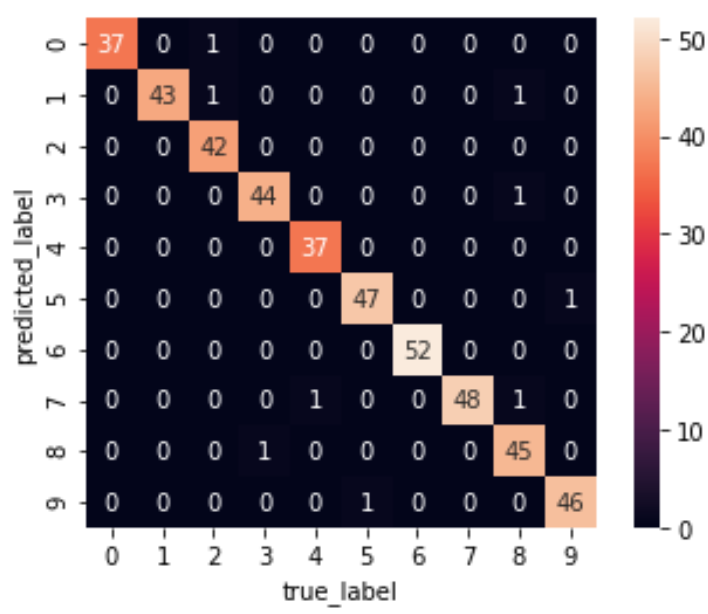

In [1]:
from IPython import display
display.Image("cm.png", width="500", height="300")

<h4> Calculate: precision, recall and f1-score for the digit 8.

- <h4> Ex2: For the following data: 
    
x | 1 | 2 | 3 |
    
y | 2 | 4 | 5 |

we built a linear model $y=1.5x+0.67$
    
Answer the folllowing question:
- Predict $y$ value for $x=4$.
- What is the $R^2$ and $MSE$ for such as model? (on training data, write expression only)


- <h4> Ex3: For the following data: 
    
    
x | 1 | 2 | 3 |
    
y | 0 | 0 | 1 |

we built two logistic regression models:

- $p(x) = \frac{1}{1+e^{-47x+116}}$ (model 1)
    
    
- $p(x) = \frac{1}{1+e^{-5x+3}}$ (model 2)
    
    
What is the probability of $y=1$ provided $x=2$ according to both models? (write expression only). To which category you would classify it?
    
Calculte $BCE$ for both models. (on training data, write expression only)

<h4> Ex4: Using the gradient descent algorithm, find the minimum value of the function $f(w) = w^2 - 4w$. Starts with $w_0=1$. Show the first three iterations.

<h4> Ex5: Propose an example of a linear function that separates the two classes of data $A = \{(4,3), (3,1), (4,2)\}$, $B = \{(1,3), (2,4)\}$. Calculate the margin between the proposed line and the set of points.


Exercises to implement 

<h4> Exercise1:  The file proteases.fa contains sequences of bacterial serine proteases. These enzymes have a catalytic center that includes, among others, a serine residue, which acts as a nucleophile and attacks peptide bonds. For the sequences in the file, the position of the catalytic serine is known — for example, in the first sequence, it is the serine at position 354.
    
>The goal of this task is to identify sequence patterns that are associated with the catalytic serine and, ultimately, to determine which serines in the sequences from the file test.fa are likely to be part of the catalytic center.

- Provide the position of the catalytic serine for the following sequences:
                      s1: ___, s2: ___, s3: ___
- Describe your strategy in a few concise points.


- Read the train data

In [4]:
f = open("proteases.fa", "r")
names, sequences = [], [] #names and sequences
for line in f:
    if line.startswith(">"):
        names.append(line[1:].replace("\n",""))
    else:
        sequences.append(line.replace("\n",""))

In [5]:
print(names)

['Q9AER6.t', 'P41363.t', 'P08594.t', 'P80146.t', 'P30199.m', 'Q8KH46.m', 'H2JJ14.m', 'MER0016986.m', 'F4HL71.h', 'Q5JIZ5.h', 'G0EFG7.h', 'B8D5T9.h', 'B8CU08.p', 'K4M7H8.p', 'Q480E3.p', 'Q8GB52.p']


In [6]:
print(sequences[0]) #the first sequnece

MNIIPLFAFSKIAKEIYTLQKIDKRLLNKASYLRSECVPAILYSNLPYETLKSKIEKFGGSIKFEIPIIKGWSVNLPCDKLKHFASIKGIHFIAEDSLVKLQLHIATQEIASRKANDLGYTGKGITIAFLDTGIYPHPDFTKPKNRIIAFYDVVNGKKQPYDDNGHGTHVAGDAAGNGYASNGKYKGVAPEANIVAVKVLDSYGRGSSSDILAGMQWVLDNKEKYNIRIVSLSIGETPALPTFLDPLVRGVDTLWKNGIVVVVAAGNSGPNYNSITSPGTSRNAITVGAVDDKRTPDIEDDEVAKFSGRGGPYLYKPDVVAPGVKIVSTASGNVPFGADEIMINKPYRSATGTSMATPMVAGAVALLLEKNSRLTNVEIKNILKTTATKINEAGLWTQGSGMINIEEALKKV


- Where is the active site serine located?

In [7]:
proteins = ['Q9AER6.t', 'P41363.t', 'P08594.t', 'P80146.t', 'P30199.m', 'Q8KH46.m', 'H2JJ14.m', 'MER0016986.m', 'F4HL71.h', 'Q5JIZ5.h', 'G0EFG7.h', 'B8D5T9.h', 'B8CU08.p', 'K4M7H8.p', 'Q480E3.p', 'Q8GB52.p']
S_positions = [354,307,349,356,402,359,386,394,348,382,350,343,452,314,498,359] #Position in the sequence; remember, if processed in Python, we should subtract 1 as indexing starts from 0.

In [8]:
print(dict(zip(proteins, S_positions)))

{'Q9AER6.t': 354, 'P41363.t': 307, 'P08594.t': 349, 'P80146.t': 356, 'P30199.m': 402, 'Q8KH46.m': 359, 'H2JJ14.m': 386, 'MER0016986.m': 394, 'F4HL71.h': 348, 'Q5JIZ5.h': 382, 'G0EFG7.h': 350, 'B8D5T9.h': 343, 'B8CU08.p': 452, 'K4M7H8.p': 314, 'Q480E3.p': 498, 'Q8GB52.p': 359}


- Read the test data

In [10]:
f = open("dane/test.fa", "r")
names_test, sequences_test = [], [] #names and sequences
for line in f:
    if line.startswith(">"):
        names_test.append(line[1:].replace("\n",""))
    else:
        sequences_test.append(line.replace("\n",""))

In [11]:
print(names_test)

['s1', 's2', 's3']


In [12]:
print(sequences_test)

['MCIIPLFVFSKIAKEIYTTQKIDKRLLNKASYLRSECVGEAILYSNDLPYETLKSKIHKFGGSIKFEIPMIKGWSVNLPCDKLKHFASIKGIHAIAEDSWVTLQMHIMTQEIASRKPNDLGYTGSGITIATLDTGIPHPDFTKPKNRYIAFYDVVNGKKQPYDDNGHGGTHSAGDAAGNEYASNGKYKGVAPEANPVAVKVLDSYGRGDSSDILAGMQWVLDNKEKYSNIRVSLSMIGEHTPPLPTFLDPLVCGVDTLWKNGIVSVVVAAGNSGPNYNSITSPGTSRNAITVGAVDDKRTPDIEDDEVAHYGRGGPYLYKHDVVAPGVKIVSTRASGNVPFGADEIMINKPYRSAKGTSMATPMVAGAVALLHKNSRLTNVEIKNILKHTTATKLINEAGLWTQGSAMINIEEALKKP', 'MDRGGLWLLLGLLVLSACSRSNPPAASTQEAPLLGLECPFAIPGRYGTSMAENAGWVKPALEAEKAMLETGLMQPQGLQAHQALRTLGLEGARVDKVYTAALRGVAVWVPDQELARLRQDHRVAYIEADQEVRAFAGTSMATWGLDRNIDSLTLPLDGRYTYTATGAGVGHAYVVDTGQLLSHQEFTGRIGKGYDAITPGGSAQDCYGHGTHFAGTIGGTTKGVAKGVTLHPVRVLDCNGSVSNSSVIAGLDPVTQNHVKPAVINMSLGKGATSTALDTAVMNAINRGVTVVVAAGADNRDLCFYSPARVTAAITGAATTSTDYRASFINYGRCGDQFEPGQSITSAWYTSSTAQTNTISGTSMATWHVTGAAALYLQWYPTATPKQVASALLYYAPNVKLAGRYCSPNLKLYTPF', 'MKKFGCVVLALFLVNLMAGSVLAAPQKQPAVRNVSMVKNYGLLTPGLFKKVQRMSWDQEVSTIIMFDQRNQADKEKAVEILDFLGAKIKYNYHIIPALAVKIKVKDLLIIAGLMDTGYFGNAQLSGVQFIQEDYVVKVAVRTPEGLDASAAQVMRT

In [13]:
#YOUR CODE
#
#
#
#
#
#
#
#
#

<h4> Exercise2: There are 200 bacteria and their corresponding gene sequences. The first 100 are susceptible to the antibiotic, while the remaining 100 are antibiotic-resistant. Build a classification model that, based on the DNA sequence of a given bacterium, predicts whether it is resistant or not.


In [60]:
import pickle

# Wczytanie z pliku
with open('bakterie.pkl', 'rb') as f:
    bakterie = pickle.load(f)

In [61]:
print(bakterie[0]) #pierwsza bakteria

['...']
